In [364]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from glob import glob
from Charts.ploTools import *
from Charts.resumeTools import *

In [365]:
FOLDER_EXP = 'OptimizeIterationsResults/OptunaDDPGExpBase*'
METRICS_EXP = '/00000*/*/metrics_resume_testing.pkl'

In [366]:
folder_list = [
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment05',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment07',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize10',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_ShuffleDaysTrue',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_Total']

In [367]:
def getMetrics(folder, metrica='net_worths_delta_acum'):
    path_files = glob(folder + METRICS_EXP)
    key = folder.split('\\OptunaDDPGExpBase_')[-1]
    metrics_resume_testing_avg = last_data_list(path_files)
    metricDDPG = metrics_resume_testing_avg['DDPG Agent'][metrica]
    return key, metricDDPG

In [368]:
def getOtherMetric(folder, metrica):
    path_files = glob(folder + METRICS_EXP)
    key = folder.split('\\OptunaDDPGExpBase_')[-1]
    metrics_resume_testing_avg = mean_resume_data(path_files)
    metricDDPG = metrics_resume_testing_avg['DDPG Agent'][metrica]
    return key, metricDDPG

In [369]:
finalPairs = [getMetrics(folder) for folder in folder_list]
df = pd.DataFrame(finalPairs, columns=['key', 'metricDDPG'])
df['mean'] = df.metricDDPG.apply(lambda x: np.mean(x))
df['std'] = df.metricDDPG.apply(lambda x: np.std(x))
from scipy.stats import ttest_ind
df.sort_values(by='mean', ascending=True, inplace=True)

In [370]:
df[['key','mean','std']]

,key,mean,std
0,CorrelationPunishment05,97188.516325,18178.140364
5,ShuffleDaysTrue,98482.685681,23612.565633
6,Total,102749.467008,15029.617936
2,RewardNetProfit,103358.222816,11783.746257
1,CorrelationPunishment07,103858.157853,12876.086395
3,RMemorySize10,106191.947818,14748.323491
4,RMemorySize3,114868.257359,9490.584474


In [371]:
def checkMeanGreaterTTest(metricA, metricB, df):
    metricAData = df[df['key'] == metricA]['metricDDPG'].values[0]
    metricBData = df[df['key'] == metricB]['metricDDPG'].values[0]

    # Perform t-test
    if np.mean(metricAData) > np.mean(metricBData):
        alternative_to_use = 'greater'
    else:
        alternative_to_use = 'less'
    t_stat, p_value = ttest_ind(metricAData, metricBData, alternative=alternative_to_use)
    result = 0
    if p_value < 0.05: # significance level
        result = 1
    return result

def tTestMeanGreaterTTest(metricA, metricB, df):
    metricAData = df[df['key'] == metricA]['metricDDPG'].values[0]
    metricBData = df[df['key'] == metricB]['metricDDPG'].values[0]

    # Perform t-test
    if np.mean(metricAData) > np.mean(metricBData):
        alternative_to_use = 'greater'
    else:
        alternative_to_use = 'less'
    t_stat, p_value = ttest_ind(metricAData, metricBData, alternative=alternative_to_use)
    return p_value

In [372]:
ExperimentList = df.key.to_list()
ExperimentList

['CorrelationPunishment05',
 'ShuffleDaysTrue',
 'Total',
 'RewardNetProfit',
 'CorrelationPunishment07',
 'RMemorySize10',
 'RMemorySize3']

In [373]:
# Improve the create_p_value_matrix function to return a DataFrame with the experiment names as both rows and columns
def create_flag_p_value_matrix(df, experimentList):
    num_experiments = len(experimentList)
    p_value_matrix = np.zeros((num_experiments, num_experiments))

    for i in range(num_experiments):
        for j in range(num_experiments):
            if i != j:
                exp1Name = experimentList[i]
                exp2Name = experimentList[j]
                p_value_matrix[i, j] = checkMeanGreaterTTest(exp1Name, exp2Name, df)

    return pd.DataFrame(p_value_matrix, index=experimentList, columns=experimentList)

def create_p_value_matrix(df, experimentList):
    num_experiments = len(experimentList)
    p_value_matrix = np.ones((num_experiments, num_experiments))

    for i in range(num_experiments):
        for j in range(num_experiments):
            if i != j:
                exp1Name = experimentList[i]
                exp2Name = experimentList[j]
                p_value_matrix[i, j] = tTestMeanGreaterTTest(exp1Name, exp2Name, df)

    return pd.DataFrame(p_value_matrix, index=experimentList, columns=experimentList)

In [374]:
#improve the appearance of the matrix put the 1s in green and the 0 in red
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl

def plot_flag_p_value_matrix(p_value_matrix):
    # Create a custom colormap
    cmap = mcolors.ListedColormap(['red', 'green'])
    bounds = [0, 0.5, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(p_value_matrix, annot=True, fmt=".0f", cmap=cmap, norm=norm, cbar=False,
                xticklabels=p_value_matrix.columns, yticklabels=p_value_matrix.index)
    plt.title('P-value Matrix')
    plt.xlabel('Experiments')
    plt.ylabel('Experiments')
    plt.show()

# Create the p-value matrix
p_value_matrix = create_flag_p_value_matrix(df, ExperimentList)
# Plot the p-value matrix
#plot_flag_p_value_matrix(p_value_matrix)

# Para Net Worth

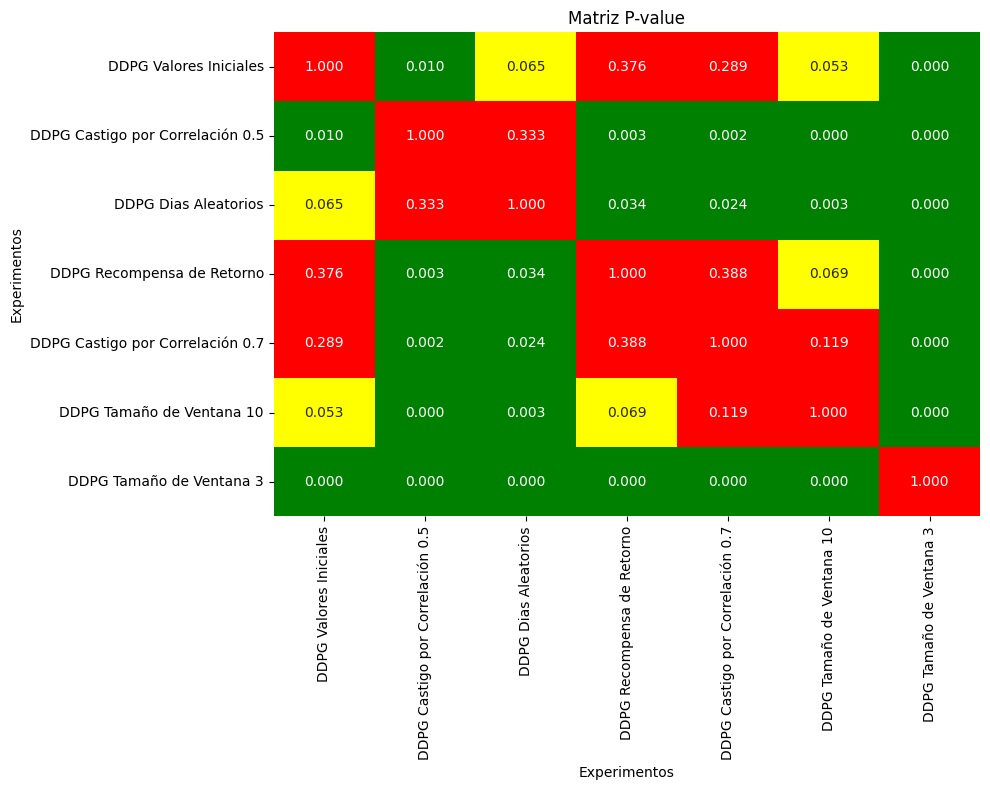

In [400]:
create_p_value_matrix(df, ExperimentList)
#improve the appearance of the p values matrix with a color scale , but when the p value is less than 0.05 put the color in green and when the p value is grater than 0.05 use a scale of yellow to red
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl

def plot_p_value_matrix(p_value_matrix, path_to_save=None, title='Matriz P-value'):
    # Create a custom colormap
    cmap = mcolors.ListedColormap(['green', 'yellow', 'red'])
    bounds = [0, 0.05, 0.1, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create the heatmap
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(p_value_matrix, annot=True, fmt=".3f", cmap=cmap, norm=norm, cbar=False,
                xticklabels=p_value_matrix.columns, yticklabels=p_value_matrix.index)
    plt.title(title)
    plt.xlabel('Experimentos')
    plt.ylabel('Experimentos')

    plt.tight_layout()
    if path_to_save:
        fig.savefig(path_to_save + f'lastNetWorth_perAgent.png')
    plt.show()
# Create the p-value matrix

p_value_matrix = create_p_value_matrix(df, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(p_value_matrix)

In [376]:
create_p_value_matrix(df, ExperimentList)

,CorrelationPunishment05,ShuffleDaysTrue,Total,RewardNetProfit,CorrelationPunishment07,RMemorySize10,RMemorySize3
CorrelationPunishment05,1.000000e+00,3.330628e-01,9.986613e-03,2.538790e-03,1.626651e-03,9.101527e-05,1.388979e-15
ShuffleDaysTrue,3.330628e-01,1.000000e+00,6.546221e-02,3.376092e-02,2.405787e-02,3.303180e-03,5.315314e-10
Total,9.986613e-03,6.546221e-02,1.000000e+00,3.757318e-01,2.889446e-01,5.315586e-02,6.616163e-11
RewardNetProfit,2.538790e-03,3.376092e-02,3.757318e-01,1.000000e+00,3.879746e-01,6.883306e-02,6.959178e-13
CorrelationPunishment07,1.626651e-03,2.405787e-02,2.889446e-01,3.879746e-01,1.000000e+00,1.190292e-01,4.586755e-11
RMemorySize10,9.101527e-05,3.303180e-03,5.315586e-02,6.883306e-02,1.190292e-01,1.000000e+00,9.325165e-07
RMemorySize3,1.388979e-15,5.315314e-10,6.616163e-11,6.959178e-13,4.586755e-11,9.325165e-07,1.000000e+00


In [377]:
df

,key,metricDDPG,mean,std
0,CorrelationPunishment05,"[108420.27670238707, 93094.6158597548, 96093.3...",97188.516325,18178.140364
5,ShuffleDaysTrue,"[89247.34788946286, 81756.89601074638, 78869.7...",98482.685681,23612.565633
6,Total,"[112933.599162264, 90866.15500873412, 87807.27...",102749.467008,15029.617936
2,RewardNetProfit,"[79898.02536325659, 97896.36148006076, 88716.1...",103358.222816,11783.746257
1,CorrelationPunishment07,"[96929.16143923393, 106832.43371002043, 108714...",103858.157853,12876.086395
3,RMemorySize10,"[90638.99443567405, 104990.86207490665, 103097...",106191.947818,14748.323491
4,RMemorySize3,"[87678.13480611044, 111154.97668198236, 126935...",114868.257359,9490.584474


In [ ]:
df['key'] = ['DDPG Castigo por Correlación 0.5', 
  'DDPG Dias Aleatorios',
  'DDPG Valores Iniciales',
  'DDPG Recompensa de Retorno',
  'DDPG Castigo por Correlación 0.7',
  'DDPG Tamaño de Ventana 10',
  'DDPG Tamaño de Ventana 3']
df['first'] = df['key'].apply(lambda x: 1 if x == 'DDPG Valores Iniciales' else 0)
df.sort_values(by='first', ascending=False, inplace=True)

In [389]:
ExperimentList = df.key.to_list()

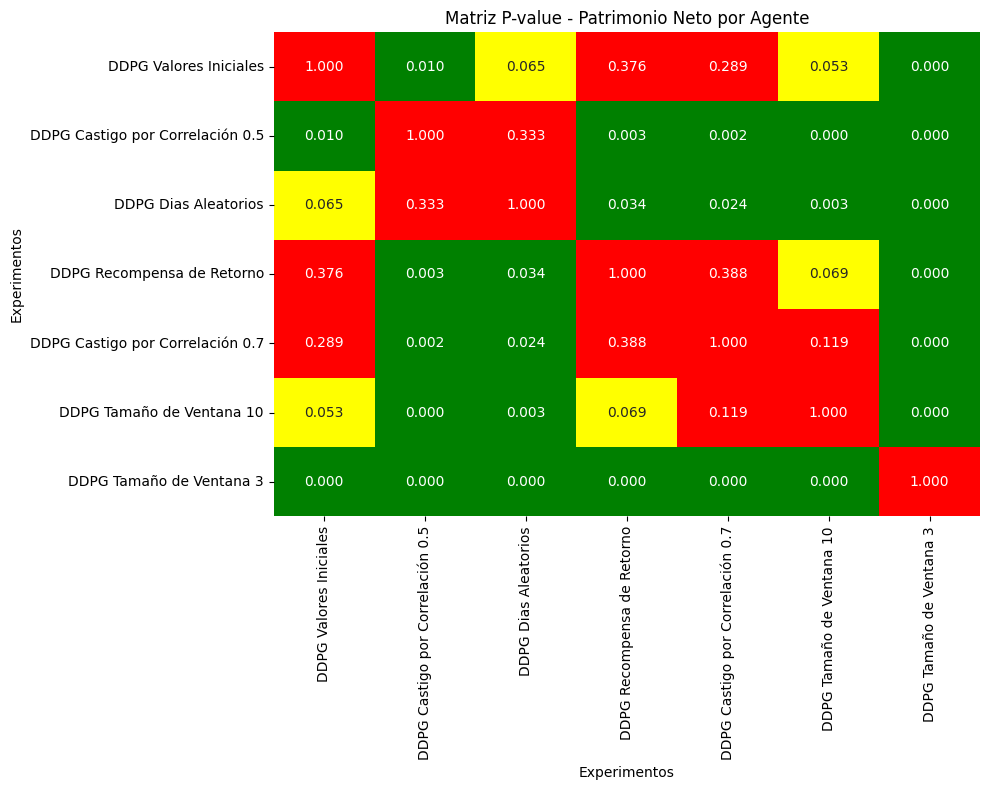

In [401]:

p_value_matrix = create_p_value_matrix(df, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(p_value_matrix, path_to_save='G11_pvalueMatrix_general', title='Matriz P-value - Patrimonio Neto por Agente')

# Para Sharpe Ratio

In [402]:
finalPairs_df_SR = [getOtherMetric(folder, 'sharpe_ratios') for folder in folder_list]
df_SR = pd.DataFrame(finalPairs_df_SR, columns=['key', 'metricDDPG'])
df_SR['mean'] = df_SR.metricDDPG.apply(lambda x: np.mean(x))
df_SR['std'] = df_SR.metricDDPG.apply(lambda x: np.std(x))
df_SR.sort_values(by='mean', ascending=True, inplace=True)

In [383]:
# Create the p-value matrix
SR_p_value_matrix = create_flag_p_value_matrix(df_SR, ExperimentList)
# Plot the p-value matrix
#plot_flag_p_value_matrix(SR_p_value_matrix)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [404]:
df_SR

,key,metricDDPG,mean,std
5,ShuffleDaysTrue,"[2.2395689289324867, -1.8887206473859133, 0.03...",-0.033635,0.859153
0,CorrelationPunishment05,"[9.312332691510635, -0.6881515268881836, -5.34...",0.191632,4.446268
6,Total,"[10.95671633772094, -3.989270509154818, -6.689...",0.254661,4.863861
2,RewardNetProfit,"[11.180965748643168, -1.3584879998566075, -6.8...",0.346089,4.849739
1,CorrelationPunishment07,"[10.74549319598135, -2.5283242774461323, -6.12...",0.395448,4.875638
3,RMemorySize10,"[8.551633802600529, -1.7827154561258225, -6.44...",0.575155,5.160500
4,RMemorySize3,"[8.59806726273464, -3.758932870787247, -3.6849...",1.114061,6.090892


In [405]:
df_SR['key'] = ['DDPG Dias Aleatorios',
  'DDPG Castigo por Correlación 0.5', 
  'DDPG Valores Iniciales',
  'DDPG Recompensa de Retorno',
  'DDPG Castigo por Correlación 0.7',
  'DDPG Tamaño de Ventana 10',
  'DDPG Tamaño de Ventana 3']
df_SR['first'] = df_SR['key'].apply(lambda x: 1 if x == 'DDPG Valores Iniciales' else 0)
df_SR.sort_values(by='first', ascending=False, inplace=True)
ExperimentList = df_SR.key.to_list()
df_SR

,key,metricDDPG,mean,std,first
6,DDPG Valores Iniciales,"[10.95671633772094, -3.989270509154818, -6.689...",0.254661,4.863861,1
5,DDPG Dias Aleatorios,"[2.2395689289324867, -1.8887206473859133, 0.03...",-0.033635,0.859153,0
0,DDPG Castigo por Correlación 0.5,"[9.312332691510635, -0.6881515268881836, -5.34...",0.191632,4.446268,0
2,DDPG Recompensa de Retorno,"[11.180965748643168, -1.3584879998566075, -6.8...",0.346089,4.849739,0
1,DDPG Castigo por Correlación 0.7,"[10.74549319598135, -2.5283242774461323, -6.12...",0.395448,4.875638,0
3,DDPG Tamaño de Ventana 10,"[8.551633802600529, -1.7827154561258225, -6.44...",0.575155,5.160500,0
4,DDPG Tamaño de Ventana 3,"[8.59806726273464, -3.758932870787247, -3.6849...",1.114061,6.090892,0


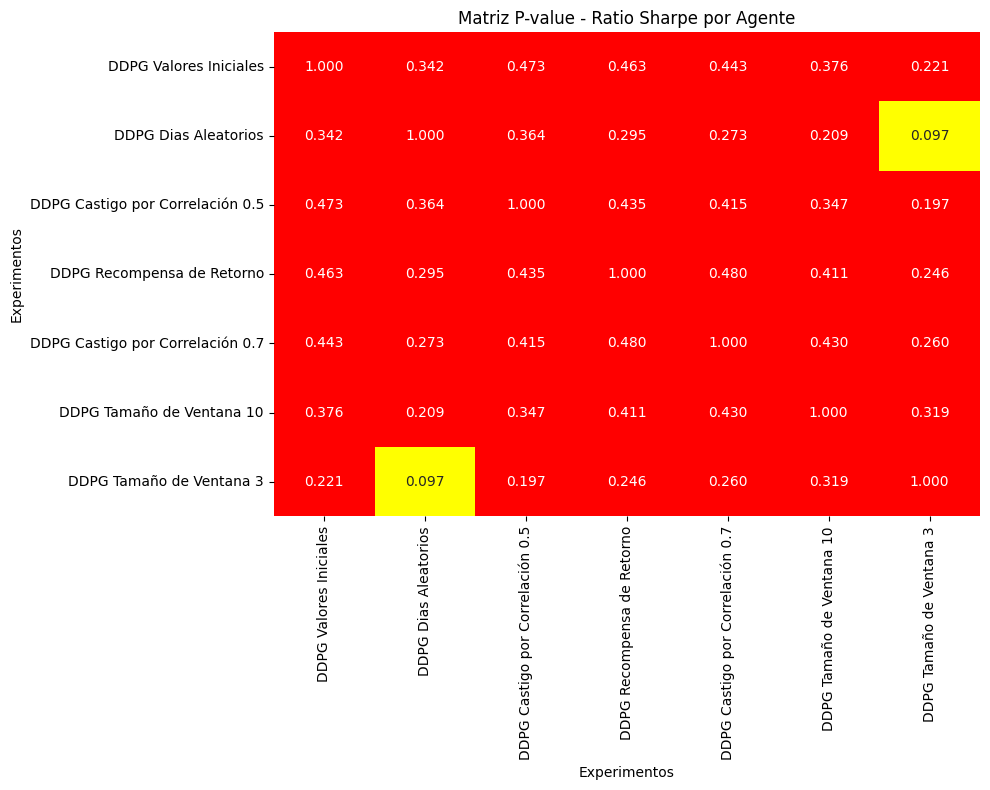

In [407]:
SR_p_value_matrix = create_p_value_matrix(df_SR, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(SR_p_value_matrix,path_to_save='G12_pvalueMatrix_general_RS', title='Matriz P-value - Ratio Sharpe por Agente')

In [ ]:
df_SR[['key','mean','std']]

,key,mean,std
5,ShuffleDaysTrue,-0.033635,0.859153
0,CorrelationPunishment05,0.191632,4.446268
6,Total,0.254661,4.863861
2,RewardNetProfit,0.346089,4.849739
1,CorrelationPunishment07,0.395448,4.875638
3,RMemorySize10,0.575155,5.160500
4,RMemorySize3,1.114061,6.090892


In [ ]:
SR_p_value_matrix

,CorrelationPunishment05,ShuffleDaysTrue,Total,RewardNetProfit,CorrelationPunishment07,RMemorySize10,RMemorySize3
CorrelationPunishment05,1.000000,0.364215,0.473378,0.434905,0.414635,0.347174,0.196977
ShuffleDaysTrue,0.364215,1.000000,0.341867,0.295321,0.272729,0.208642,0.097293
Total,0.473378,0.341867,1.000000,0.462977,0.443253,0.376200,0.221048
RewardNetProfit,0.434905,0.295321,0.462977,1.000000,0.480016,0.410672,0.245768
CorrelationPunishment07,0.414635,0.272729,0.443253,0.480016,1.000000,0.429863,0.260299
RMemorySize10,0.347174,0.208642,0.376200,0.410672,0.429863,1.000000,0.318795
RMemorySize3,0.196977,0.097293,0.221048,0.245768,0.260299,0.318795,1.000000


# Para Pearson Correlation

In [408]:
finalPairs_df_CP = [getOtherMetric(folder, 'pearson_correlations') for folder in folder_list]
df_CP = pd.DataFrame(finalPairs_df_CP, columns=['key', 'metricDDPG'])
df_CP['mean'] = df_CP.metricDDPG.apply(lambda x: np.mean(x))
df_CP['std'] = df_CP.metricDDPG.apply(lambda x: np.std(x))
df_CP.sort_values(by='mean', ascending=True, inplace=True)

In [410]:
df_CP

,key,metricDDPG,mean,std
4,RMemorySize3,"[0.034424914530963, 0.1896999713656661, 0.2227...",0.149705,0.080376
0,CorrelationPunishment05,"[0.09572084292877263, 0.24352983809510748, 0.2...",0.243408,0.077562
2,RewardNetProfit,"[0.11983460843448246, 0.2493240478436687, 0.30...",0.257323,0.077462
1,CorrelationPunishment07,"[0.1162197306257347, 0.27070827420123034, 0.29...",0.263600,0.075538
6,Total,"[0.11167008170101045, 0.25171400756750434, 0.3...",0.283429,0.086031
3,RMemorySize10,"[0.13665757634485007, 0.27226414243279967, 0.3...",0.287193,0.080839
5,ShuffleDaysTrue,"[0.2908216083722457, 0.30398030726115216, 0.28...",0.291649,0.016823


In [411]:
df_CP['key'] = [
    'DDPG Tamaño de Ventana 3',
    'DDPG Castigo por Correlación 0.5', 
    'DDPG Recompensa de Retorno',
    'DDPG Castigo por Correlación 0.7',
    'DDPG Valores Iniciales',
    'DDPG Tamaño de Ventana 10',
    'DDPG Dias Aleatorios'
  ]
df_CP['first'] = df_CP['key'].apply(lambda x: 1 if x == 'DDPG Valores Iniciales' else 0)
df_CP.sort_values(by='first', ascending=False, inplace=True)
ExperimentList = df_CP.key.to_list()
df_CP

,key,metricDDPG,mean,std,first
6,DDPG Valores Iniciales,"[0.11167008170101045, 0.25171400756750434, 0.3...",0.283429,0.086031,1
4,DDPG Tamaño de Ventana 3,"[0.034424914530963, 0.1896999713656661, 0.2227...",0.149705,0.080376,0
0,DDPG Castigo por Correlación 0.5,"[0.09572084292877263, 0.24352983809510748, 0.2...",0.243408,0.077562,0
2,DDPG Recompensa de Retorno,"[0.11983460843448246, 0.2493240478436687, 0.30...",0.257323,0.077462,0
1,DDPG Castigo por Correlación 0.7,"[0.1162197306257347, 0.27070827420123034, 0.29...",0.263600,0.075538,0
3,DDPG Tamaño de Ventana 10,"[0.13665757634485007, 0.27226414243279967, 0.3...",0.287193,0.080839,0
5,DDPG Dias Aleatorios,"[0.2908216083722457, 0.30398030726115216, 0.28...",0.291649,0.016823,0


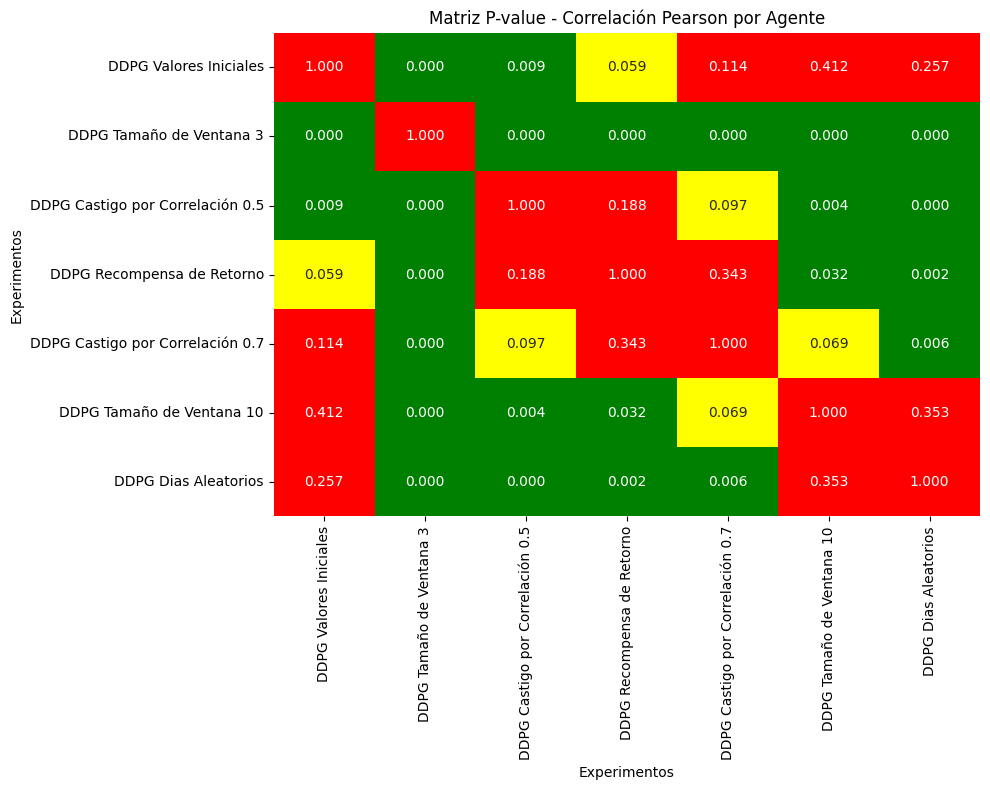

In [412]:
CP_p_value_matrix = create_p_value_matrix(df_CP, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(CP_p_value_matrix, path_to_save='G13_pvalueMatrix_general_PC', title='Matriz P-value - Correlación Pearson por Agente')

In [ ]:
df_CP[['key','mean','std']]

,key,mean,std
4,RMemorySize3,0.149705,0.080376
0,CorrelationPunishment05,0.243408,0.077562
2,RewardNetProfit,0.257323,0.077462
1,CorrelationPunishment07,0.263600,0.075538
6,Total,0.283429,0.086031
3,RMemorySize10,0.287193,0.080839
5,ShuffleDaysTrue,0.291649,0.016823


In [ ]:
CP_p_value_matrix

,CorrelationPunishment05,ShuffleDaysTrue,Total,RewardNetProfit,CorrelationPunishment07,RMemorySize10,RMemorySize3
CorrelationPunishment05,1.000000e+00,2.395606e-05,8.713948e-03,1.882094e-01,9.738544e-02,3.694123e-03,2.943702e-08
ShuffleDaysTrue,2.395606e-05,1.000000e+00,2.565691e-01,1.557593e-03,6.378130e-03,3.532094e-01,1.842283e-21
Total,8.713948e-03,2.565691e-01,1.000000e+00,5.882565e-02,1.141379e-01,4.119420e-01,1.616463e-12
RewardNetProfit,1.882094e-01,1.557593e-03,5.882565e-02,1.000000e+00,3.427586e-01,3.240804e-02,5.278662e-10
CorrelationPunishment07,9.738544e-02,6.378130e-03,1.141379e-01,3.427586e-01,1.000000e+00,6.936780e-02,5.401721e-11
RMemorySize10,3.694123e-03,3.532094e-01,4.119420e-01,3.240804e-02,6.936780e-02,1.000000e+00,1.429616e-13
RMemorySize3,2.943702e-08,1.842283e-21,1.616463e-12,5.278662e-10,5.401721e-11,1.429616e-13,1.000000e+00


# Gráfico Final

In [ ]:
df_CP

,key,metricDDPG,mean,std
4,RMemorySize3,"[0.034424914530963, 0.1896999713656661, 0.2227...",0.149705,0.080376
0,CorrelationPunishment05,"[0.09572084292877263, 0.24352983809510748, 0.2...",0.243408,0.077562
2,RewardNetProfit,"[0.11983460843448246, 0.2493240478436687, 0.30...",0.257323,0.077462
1,CorrelationPunishment07,"[0.1162197306257347, 0.27070827420123034, 0.29...",0.263600,0.075538
6,Total,"[0.11167008170101045, 0.25171400756750434, 0.3...",0.283429,0.086031
3,RMemorySize10,"[0.13665757634485007, 0.27226414243279967, 0.3...",0.287193,0.080839
5,ShuffleDaysTrue,"[0.2908216083722457, 0.30398030726115216, 0.28...",0.291649,0.016823


In [ ]:
CP_p_value_matrix = create_p_value_matrix(b, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(CP_p_value_matrix)

NameError: name 'b' is not defined